In [3]:
from ucimlrepo import fetch_ucirepo 

# Fetch dataset using its ID
heart_disease = fetch_ucirepo(id=519) 
  
# Extract data as pandas dataframes 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# View the first few rows of features
print(X.head())

# Access and read dataset metadata
print(heart_disease.metadata.num_instances)
print(heart_disease.variables)


    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  
0        0     4  
1        0     6  
2        1     7  
3        0     7  
4        

In [2]:
from ucimlrepo import fetch_ucirepo

# Heart failure clinical records dataset
dataset = fetch_ucirepo(id=519)
X = dataset.data.features
y = dataset.data.targets

df = X.copy()
df['DEATH_EVENT'] = y  # or merge however your target is structured

death_count = (df['DEATH_EVENT'] == 1).sum()
total = len(df)
print(f"Deaths: {death_count} out of {total} ({death_count/total:.1%})")

Deaths: 96 out of 299 (32.1%)


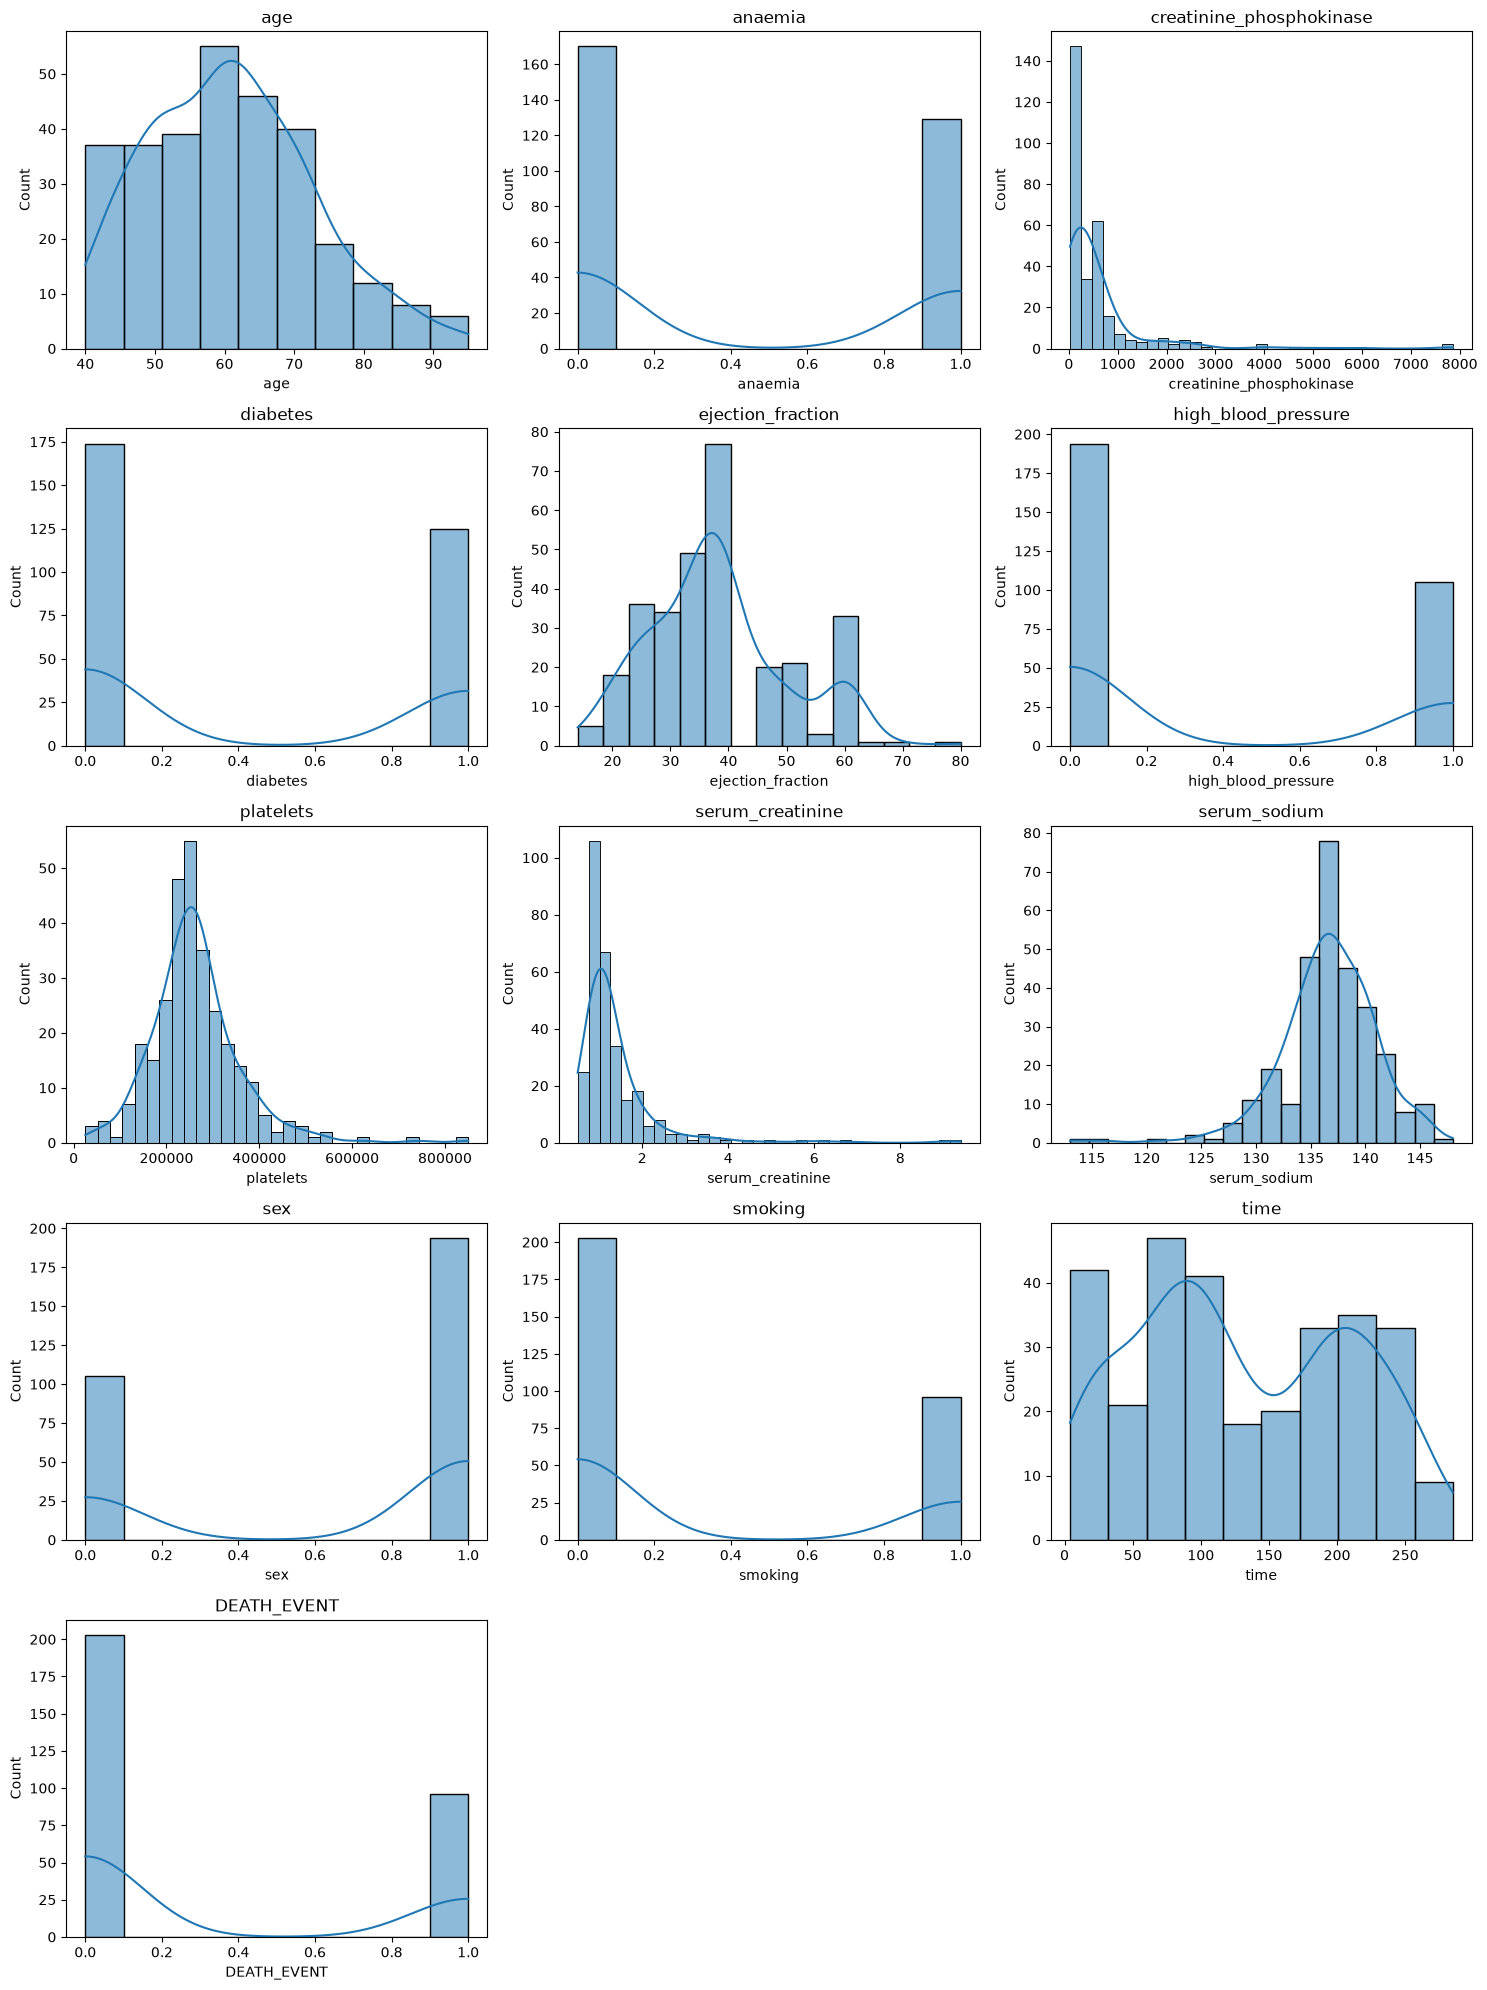

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df should be your full dataframe (features + target)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

target_col = 'DEATH_EVENT'

# Typical continuous features in this dataset
continuous_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                    'platelets', 'serum_creatinine', 'serum_sodium', 'time']

# Filter to only columns that actually exist in your df
continuous_cols = [c for c in continuous_cols if c in df.columns]

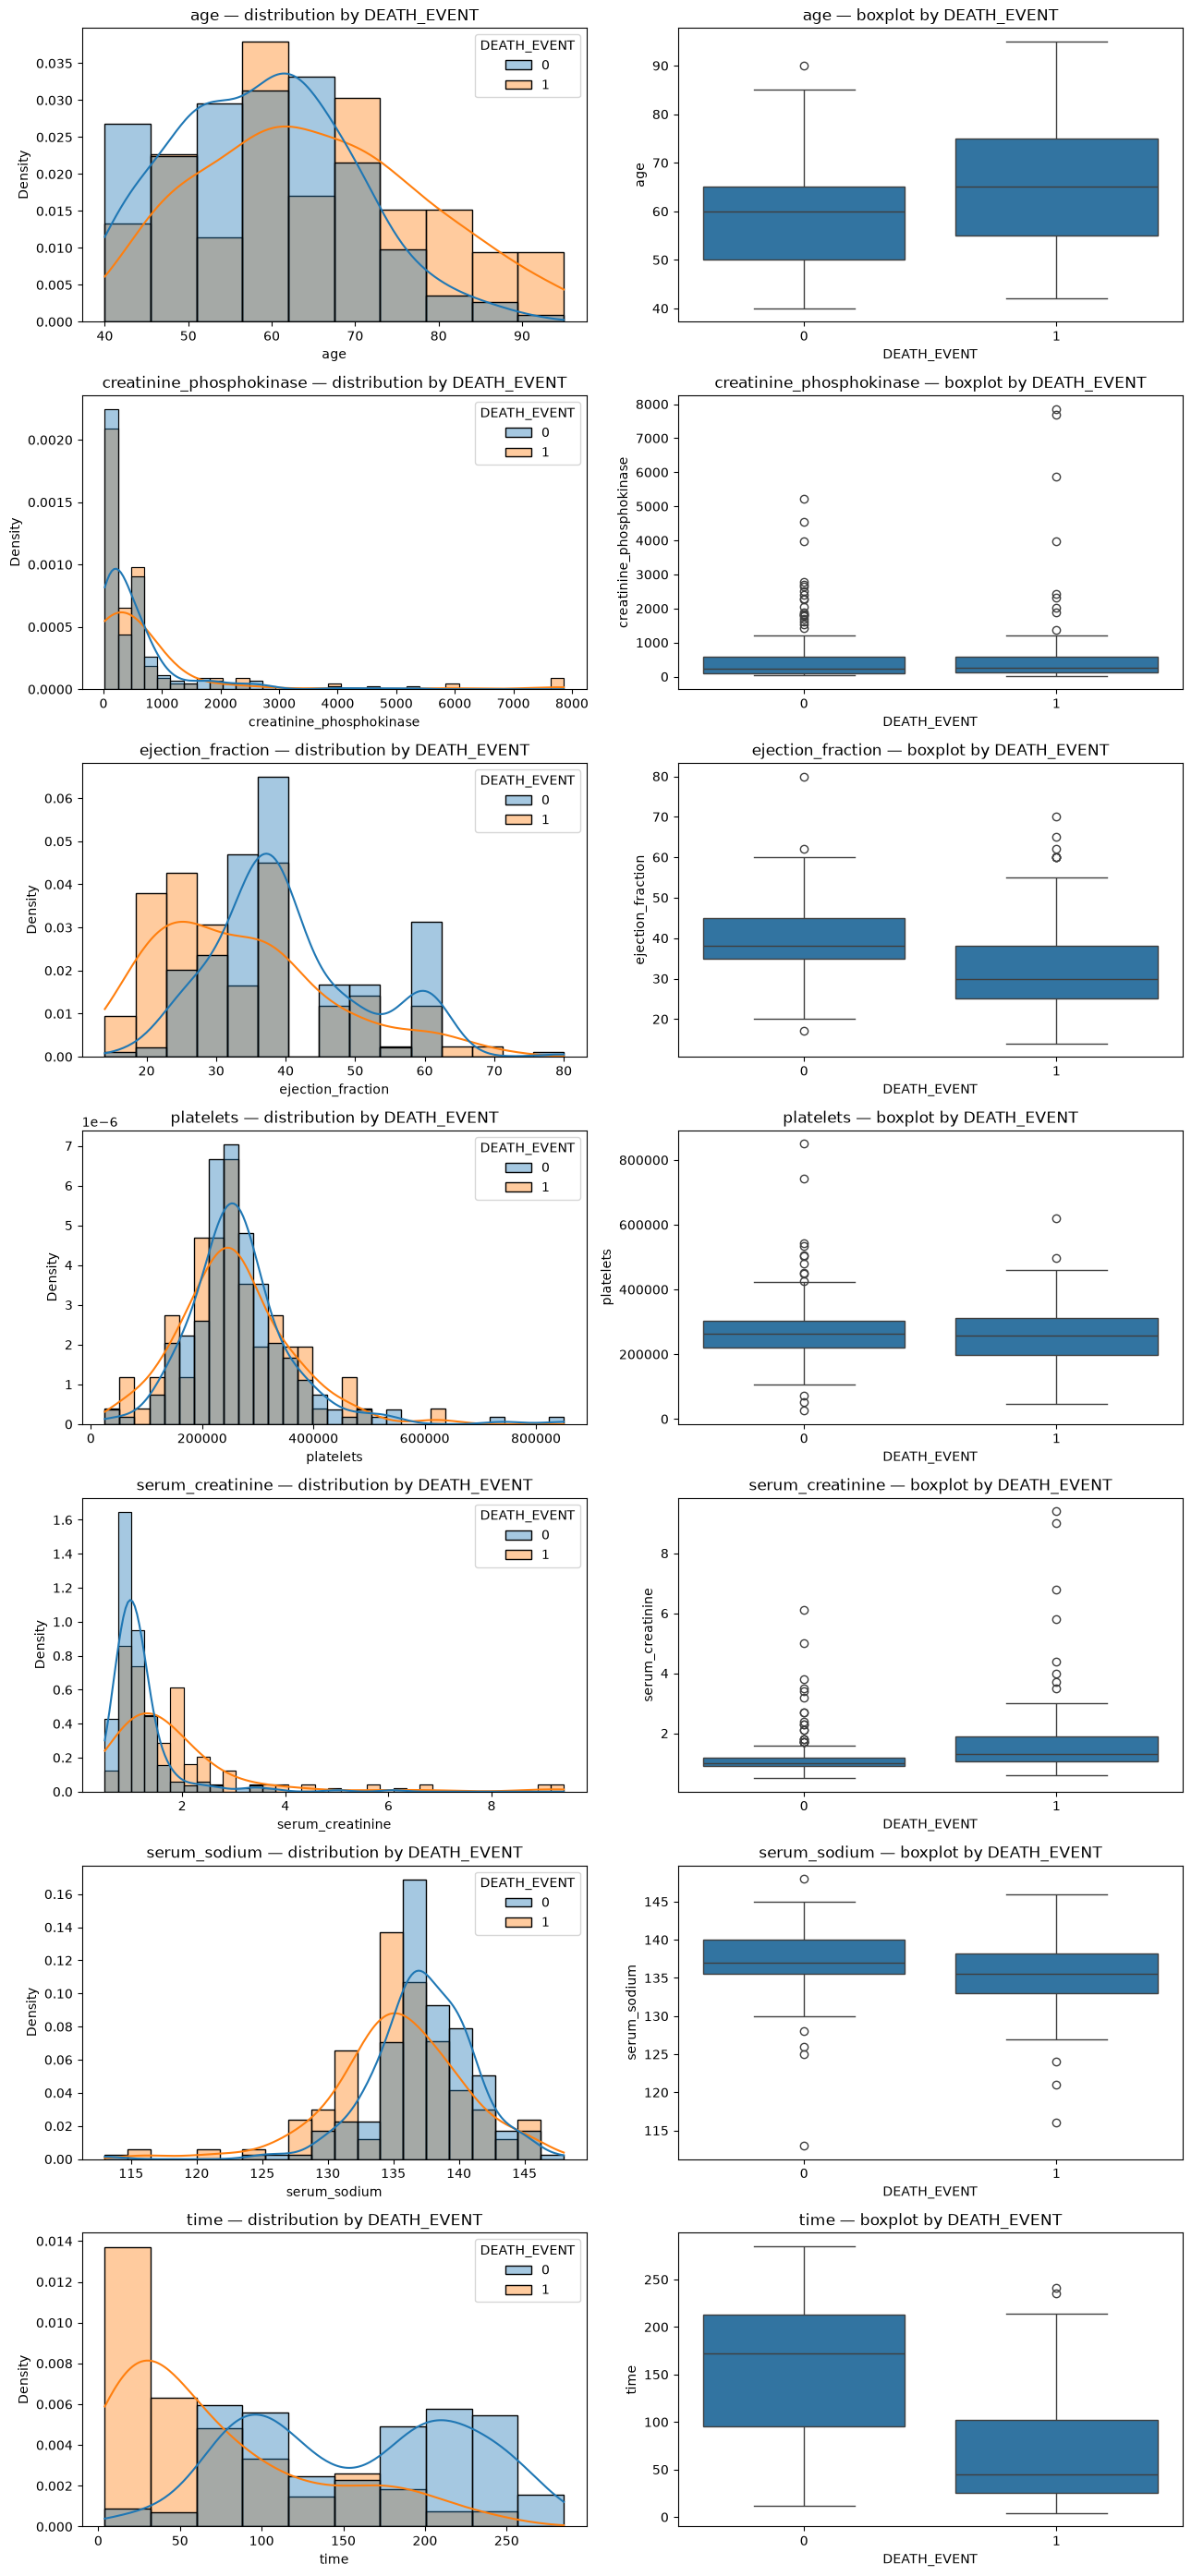

In [6]:
n_cols = 2
n_rows = len(continuous_cols)

fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows))

for i, col in enumerate(continuous_cols):
    # Overlaid KDE/histogram
    sns.histplot(data=df, x=col, hue=target_col, kde=True,
                 stat='density', common_norm=False, alpha=0.4, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — distribution by DEATH_EVENT')

    # Boxplot
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — boxplot by DEATH_EVENT')

plt.tight_layout()
plt.show()

In [7]:
# Mean of every feature by group
group_means = df.groupby(target_col).mean()
print(group_means.T)  # transpose so features are rows, easy to scan

# Correlation of each feature with DEATH_EVENT
correlations = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print(correlations)

DEATH_EVENT                           0              1
age                           58.761906      65.215281
anaemia                        0.408867       0.479167
creatinine_phosphokinase     540.054187     670.197917
diabetes                       0.418719       0.416667
ejection_fraction             40.266010      33.468750
high_blood_pressure            0.325123       0.406250
platelets                 266657.489901  256381.044792
serum_creatinine               1.184877       1.835833
serum_sodium                 137.216749     135.375000
sex                            0.650246       0.645833
smoking                        0.325123       0.312500
time                         158.339901      70.885417
time                       -0.526964
serum_creatinine            0.294278
ejection_fraction          -0.268603
age                         0.253729
serum_sodium               -0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase  

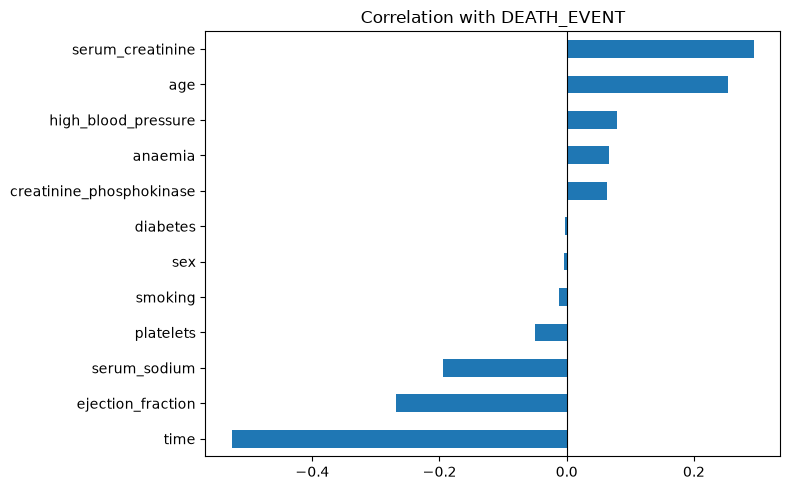

In [8]:
# Optional: visualize correlations as a bar chart
plt.figure(figsize=(8, 5))
correlations.sort_values().plot(kind='barh')
plt.title(f'Correlation with {target_col}')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# 1. Define X and y
X = df.drop(columns=['DEATH_EVENT', 'time'])
y = df['DEATH_EVENT']

# 2. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Verify the split
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Death rate — full dataset: {y.mean():.1%}")
print(f"Death rate — train: {y_train.mean():.1%}")
print(f"Death rate — test:  {y_test.mean():.1%}")

Train shape: (239, 11), Test shape: (60, 11)
Death rate — full dataset: 32.1%
Death rate — train: 32.2%
Death rate — test:  31.7%


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# 1. Pipeline: StandardScaler -> LogisticRegression
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. StratifiedKFold CV on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['roc_auc', 'average_precision']

cv_results = cross_validate(
    log_reg_pipe, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# 3. Report mean ± std across folds
print("Logistic Regression (5-fold CV)")
print(f"  ROC-AUC:   {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")
print(f"  PR-AUC:    {cv_results['test_average_precision'].mean():.3f} ± {cv_results['test_average_precision'].std():.3f}")
print(f"  Per-fold ROC-AUC: {np.round(cv_results['test_roc_auc'], 3)}")
print(f"  Per-fold PR-AUC:  {np.round(cv_results['test_average_precision'], 3)}")

Logistic Regression (5-fold CV)
  ROC-AUC:   0.805 ± 0.052
  PR-AUC:    0.685 ± 0.041
  Per-fold ROC-AUC: [0.832 0.879 0.82  0.729 0.767]
  Per-fold PR-AUC:  [0.633 0.756 0.678 0.666 0.692]


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)

rf_results = cross_validate(
    rf_clf, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("\nRandom Forest (5-fold CV)")
print(f"  ROC-AUC:   {rf_results['test_roc_auc'].mean():.3f} ± {rf_results['test_roc_auc'].std():.3f}")
print(f"  PR-AUC:    {rf_results['test_average_precision'].mean():.3f} ± {rf_results['test_average_precision'].std():.3f}")
print(f"  Per-fold ROC-AUC: {np.round(rf_results['test_roc_auc'], 3)}")
print(f"  Per-fold PR-AUC:  {np.round(rf_results['test_average_precision'], 3)}")


Random Forest (5-fold CV)
  ROC-AUC:   0.776 ± 0.043
  PR-AUC:    0.662 ± 0.039
  Per-fold ROC-AUC: [0.804 0.836 0.782 0.719 0.74 ]
  Per-fold PR-AUC:  [0.633 0.723 0.696 0.628 0.632]


In [12]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import matplotlib.pyplot as plt
import joblib

# 1. Wrap LR pipeline in CalibratedClassifierCV, fit on full training set
calibrated_lr = CalibratedClassifierCV(log_reg_pipe, method='sigmoid', cv=5)
calibrated_lr.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0022C0A4BF110>, <sk

In [13]:
# Predicted probabilities on the held-out test set
y_proba = calibrated_lr.predict_proba(X_test)[:, 1]

# Final numbers
test_roc_auc = roc_auc_score(y_test, y_proba)
test_pr_auc = average_precision_score(y_test, y_proba)
test_brier = brier_score_loss(y_test, y_proba)

print("=== Final Test Set Performance ===")
print(f"ROC-AUC:     {test_roc_auc:.3f}")
print(f"PR-AUC:      {test_pr_auc:.3f}")
print(f"Brier score: {test_brier:.3f}")

=== Final Test Set Performance ===
ROC-AUC:     0.748
PR-AUC:      0.601
Brier score: 0.182


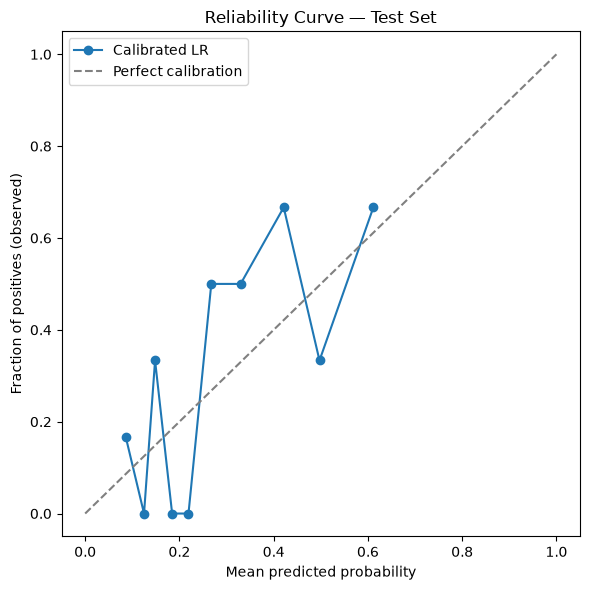

In [14]:
# Reliability curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated LR')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives (observed)')
plt.title('Reliability Curve — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
joblib.dump(calibrated_lr, 'heart_failure_risk_model.joblib')
print("Model saved to heart_failure_risk_model.joblib")

Model saved to heart_failure_risk_model.joblib


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd

skewed_cols = ['serum_creatinine', 'creatinine_phosphokinase']

log_transformer = ColumnTransformer(
    transformers=[('log', FunctionTransformer(np.log1p, validate=False), skewed_cols)],
    remainder='passthrough'
)

log_reg_pipe_logged = Pipeline([
    ('log_transform', log_transformer),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'average_precision']

cv_logged = cross_validate(log_reg_pipe_logged, X_train, y_train, cv=cv, scoring=scoring)

print("Baseline (no log)     ROC-AUC: {:.3f} ± {:.3f}  PR-AUC: {:.3f} ± {:.3f}".format(
    cv_results['test_roc_auc'].mean(), cv_results['test_roc_auc'].std(),
    cv_results['test_average_precision'].mean(), cv_results['test_average_precision'].std()))
print("With log1p            ROC-AUC: {:.3f} ± {:.3f}  PR-AUC: {:.3f} ± {:.3f}".format(
    cv_logged['test_roc_auc'].mean(), cv_logged['test_roc_auc'].std(),
    cv_logged['test_average_precision'].mean(), cv_logged['test_average_precision'].std()))

Baseline (no log)     ROC-AUC: 0.805 ± 0.052  PR-AUC: 0.685 ± 0.041
With log1p            ROC-AUC: 0.798 ± 0.049  PR-AUC: 0.672 ± 0.049


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {'clf__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}

grid_search = GridSearchCV(
    log_reg_pipe,  # <- swap if Check 1's log version won
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)
grid_search.fit(X_train, y_train)

results_df = pd.DataFrame(grid_search.cv_results_)[['param_clf__C', 'mean_test_score', 'std_test_score']]
print(results_df.sort_values('mean_test_score', ascending=False).to_string(index=False))
print(f"\nBest C: {grid_search.best_params_['clf__C']}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.3f}")

 param_clf__C  mean_test_score  std_test_score
         1.00         0.805321        0.052430
         3.00         0.804137        0.054715
        10.00         0.804137        0.054715
         0.30         0.802872        0.054368
         0.10         0.798911        0.056258
         0.03         0.795784        0.057158
         0.01         0.792173        0.053809

Best C: 1
Best CV ROC-AUC: 0.805


In [18]:
from sklearn.model_selection import RepeatedStratifiedKFold

# Use the winning pipeline + winning C from Checks 1 & 2
final_pipe = grid_search.best_estimator_  # already has the winning C baked in
# If Check 2's decision rule said "keep default C", instead do:
# final_pipe = log_reg_pipe  (or log_reg_pipe_logged)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

repeated_cv = cross_validate(final_pipe, X_train, y_train, cv=rskf, scoring=scoring)

print(f"Repeated 5-fold x5 CV ({len(repeated_cv['test_roc_auc'])} folds total)")
print(f"  ROC-AUC: {repeated_cv['test_roc_auc'].mean():.3f} ± {repeated_cv['test_roc_auc'].std():.3f}")
print(f"  PR-AUC:  {repeated_cv['test_average_precision'].mean():.3f} ± {repeated_cv['test_average_precision'].std():.3f}")

Repeated 5-fold x5 CV (25 folds total)
  ROC-AUC: 0.787 ± 0.065
  PR-AUC:  0.660 ± 0.080


In [19]:
import shap
import numpy as np
import pandas as pd

# Background sample — small reference set representing the "baseline" distribution
background = X_train.sample(n=100, random_state=42)

# Model-agnostic explainer on predict_proba directly (treats CalibratedClassifierCV as black box)
explainer = shap.Explainer(calibrated_lr.predict_proba, background)

# Compute SHAP values — do this on the test set so you're explaining genuinely held-out predictions
shap_values = explainer(X_test)

# For binary classification, predict_proba has 2 columns — take positive class (death, index 1)
shap_values_death = shap_values[..., 1]

PermutationExplainer explainer: 61it [00:14,  2.25it/s]                        


Global feature importance (mean |SHAP value|):
ejection_fraction           0.068298
age                         0.060105
serum_creatinine            0.050117
high_blood_pressure         0.031815
anaemia                     0.030047
diabetes                    0.029248
smoking                     0.022316
creatinine_phosphokinase    0.020979
sex                         0.015301
serum_sodium                0.014694
platelets                   0.009852
dtype: float64


C:\Users\Sidhartg\AppData\Local\Temp\ipykernel_32304\2626907097.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_death, X_test)


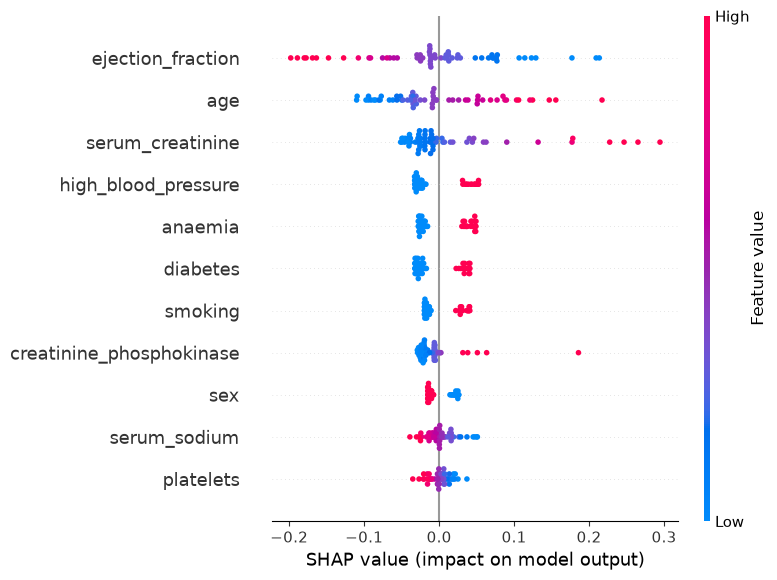

In [20]:
# Mean |SHAP| per feature, sorted
mean_abs_shap = pd.Series(
    np.abs(shap_values_death.values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print("Global feature importance (mean |SHAP value|):")
print(mean_abs_shap)

# Summary plot
shap.summary_plot(shap_values_death, X_test)

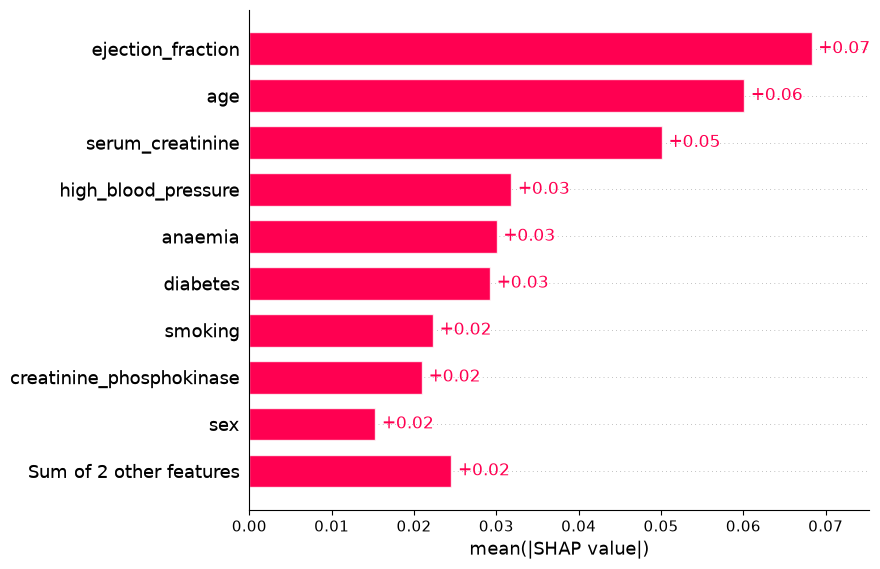

In [21]:
# Bar version, often cleaner for a writeup
shap.plots.bar(shap_values_death)

In [22]:
def get_top_factors(patient_row, shap_explanation, feature_names, n=3):
    """
    patient_row: 1D array of SHAP values for one patient (positive class)
    shap_explanation: the Explanation object slice for this patient (for .data, raw feature values)
    feature_names: list of column names, same order as patient_row
    n: how many top factors to return
    """
    shap_vals = patient_row.values if hasattr(patient_row, 'values') else patient_row
    feature_vals = patient_row.data if hasattr(patient_row, 'data') else None

    df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_vals,
        'patient_value': feature_vals
    })
    df['abs_shap'] = df['shap_value'].abs()
    df = df.sort_values('abs_shap', ascending=False).head(n)

    top_factors = []
    for _, row in df.iterrows():
        top_factors.append({
            'feature': row['feature'],
            'value': row['patient_value'],
            'shap_value': round(row['shap_value'], 4),
            'direction': 'raises risk' if row['shap_value'] > 0 else 'lowers risk'
        })
    return top_factors


# Example: top 3 factors for one patient
example_patient = shap_values_death[0]  # patient at index 0 in X_test
factors = get_top_factors(example_patient, example_patient, X_test.columns.tolist(), n=3)

for f in factors:
    print(f"{f['feature']} = {f['value']} → {f['shap_value']:+.3f} ({f['direction']})")

ejection_fraction = 30.0 → +0.072 (raises risk)
anaemia = 1.0 → +0.048 (raises risk)
smoking = 1.0 → +0.041 (raises risk)


In [23]:
import joblib

# 1. The calibrated model pipeline (scaler + LR, calibrated)
joblib.dump(calibrated_lr, 'heart_failure_risk_model.joblib')

# 2. The SHAP background sample — needed to rebuild the explainer identically tomorrow
joblib.dump(background, 'shap_background.joblib')

# 3. The exact feature schema (names + order) — the tool must feed columns in this order
feature_schema = X_train.columns.tolist()
joblib.dump(feature_schema, 'feature_schema.joblib')

print("Saved:")
print("  heart_failure_risk_model.joblib")
print("  shap_background.joblib")
print("  feature_schema.joblib")

Saved:
  heart_failure_risk_model.joblib
  shap_background.joblib
  feature_schema.joblib


In [24]:
import joblib
import shap
import pandas as pd
import numpy as np

# Reload all three, as if this were a fresh process
loaded_model = joblib.load('heart_failure_risk_model.joblib')
loaded_background = joblib.load('shap_background.joblib')
loaded_schema = joblib.load('feature_schema.joblib')

print(f"Loaded model type: {type(loaded_model)}")
print(f"Loaded background shape: {loaded_background.shape}")
print(f"Loaded schema ({len(loaded_schema)} features): {loaded_schema}")

Loaded model type: <class 'sklearn.calibration.CalibratedClassifierCV'>
Loaded background shape: (100, 11)
Loaded schema (11 features): ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


In [25]:
# Pick a couple of test patients to verify against
sample_patients = X_test.iloc[:3]

# Predictions from the ORIGINAL in-memory model (already computed earlier as y_proba)
original_preds = calibrated_lr.predict_proba(sample_patients)[:, 1]

# Predictions from the RELOADED model
reloaded_preds = loaded_model.predict_proba(sample_patients)[:, 1]

print("Original vs reloaded predicted probabilities:")
for i, (orig, reload_) in enumerate(zip(original_preds, reloaded_preds)):
    match = "✓" if np.isclose(orig, reload_) else "✗ MISMATCH"
    print(f"  Patient {i}: original={orig:.6f}  reloaded={reload_:.6f}  {match}")

Original vs reloaded predicted probabilities:
  Patient 0: original=0.426501  reloaded=0.426501  ✓
  Patient 1: original=0.310881  reloaded=0.310881  ✓
  Patient 2: original=0.210752  reloaded=0.210752  ✓


In [26]:
# Rebuild explainer using the reloaded model + reloaded background
reloaded_explainer = shap.Explainer(loaded_model.predict_proba, loaded_background)

# Re-run on the same sample patients, schema-ordered
sample_patients_ordered = sample_patients[loaded_schema]  # enforce column order from schema
reloaded_shap_values = reloaded_explainer(sample_patients_ordered)
reloaded_shap_death = reloaded_shap_values[..., 1]

# Confirm additivity still holds after reload
for i in range(len(sample_patients_ordered)):
    base = reloaded_shap_death.base_values[i]
    shap_sum = reloaded_shap_death.values[i].sum()
    reconstructed = base + shap_sum
    actual = reloaded_preds[i]
    print(f"Patient {i}: base={base:.4f} + shap_sum={shap_sum:.4f} = {reconstructed:.4f}  "
          f"(actual predict_proba={actual:.4f})  {'✓' if np.isclose(reconstructed, actual) else '✗'}")

# Top 3 factors for patient 0, using the reloaded explainer
factors = get_top_factors(reloaded_shap_death[0], reloaded_shap_death[0], loaded_schema, n=3)
print("\nTop factors for patient 0 (post-reload):")
for f in factors:
    print(f"  {f['feature']} = {f['value']} → {f['shap_value']:+.3f} ({f['direction']})")

Patient 0: base=0.3077 + shap_sum=0.1188 = 0.4265  (actual predict_proba=0.4265)  ✓
Patient 1: base=0.3077 + shap_sum=0.0032 = 0.3109  (actual predict_proba=0.3109)  ✓
Patient 2: base=0.3077 + shap_sum=-0.0970 = 0.2108  (actual predict_proba=0.2108)  ✓

Top factors for patient 0 (post-reload):
  ejection_fraction = 30.0 → +0.073 (raises risk)
  anaemia = 1.0 → +0.048 (raises risk)
  smoking = 1.0 → +0.041 (raises risk)
